In [ ]:
!nvidia-smi

Wed Jan 28 11:24:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip list | grep torch

torch                                    2.9.0+cu126
torchao                                  0.10.0
torchaudio                               2.9.0+cu126
torchdata                                0.11.0
torchsummary                             1.5.1
torchtune                                0.6.1
torchvision                              0.24.0+cu126


In [ ]:
!python --version

Python 3.12.12


In [ ]:
%pip install ultralytics roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.9/112.6 GB disk)


In [ ]:
!mkdir -p /content/datasets
%cd /content/datasets

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="nStkKxKPZsOzE8hJiNZJ")
project = rf.workspace("concussion-risk-analysis").project("nfl_collisions-kxmoy")
version = project.version(3)
dataset = version.download("yolov11")



/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to NFL_Collisions-3 in yolov11:: 100%|██████████| 2160/2160 [00:00<00:00, 3777.42it/s]


In [ ]:
%cd /content/datasets
!yolo task=detect mode=train model=/content/datasets/runs/detect/train3/weights/best.pt \ data=/content/datasets/NFL_Collisions-3/data.yaml \ epochs=50 imgsz=640 plots=True split=0.2


/content/datasets
Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/NFL_Collisions-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

In [ ]:
!ls /content/datasets/runs/detect/train3

args.yaml			 results.csv	      val_batch0_labels.jpg
BoxF1_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg     val_batch1_pred.jpg
BoxR_curve.png			 train_batch2160.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch2161.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch2162.jpg  weights
labels.jpg			 train_batch2.jpg


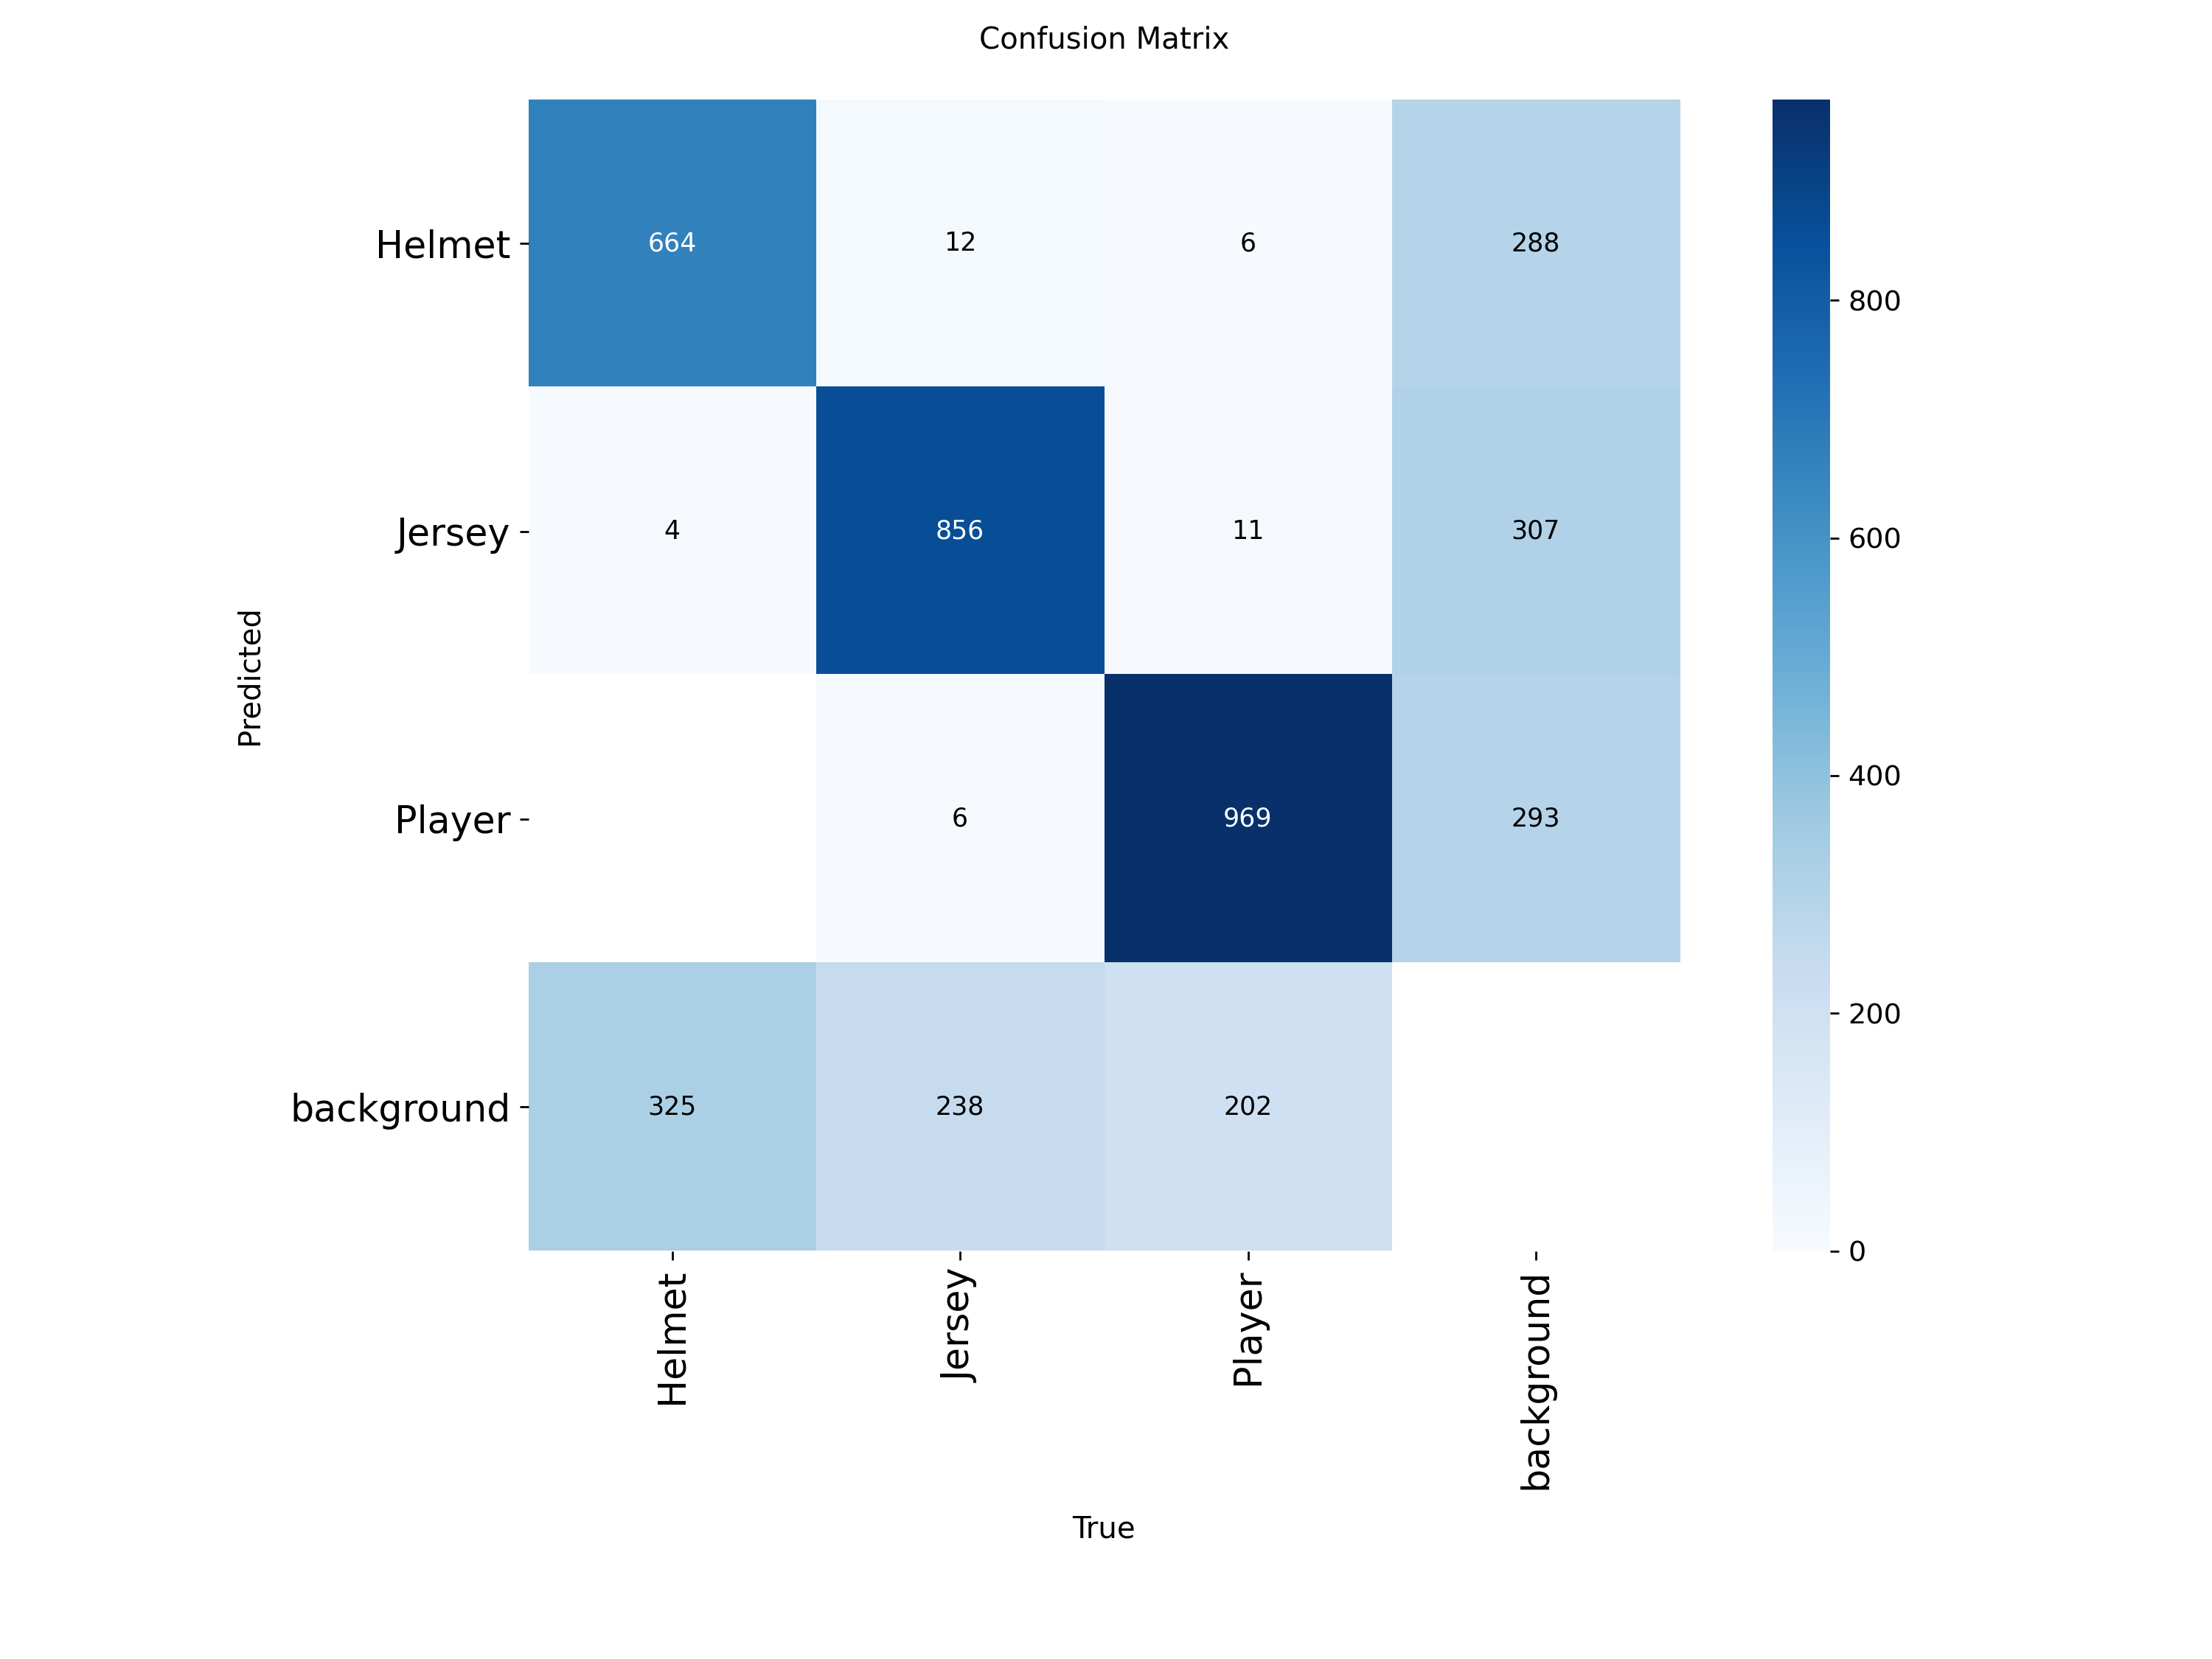

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'/content/datasets/runs/detect/train3/confusion_matrix.png', width=600)

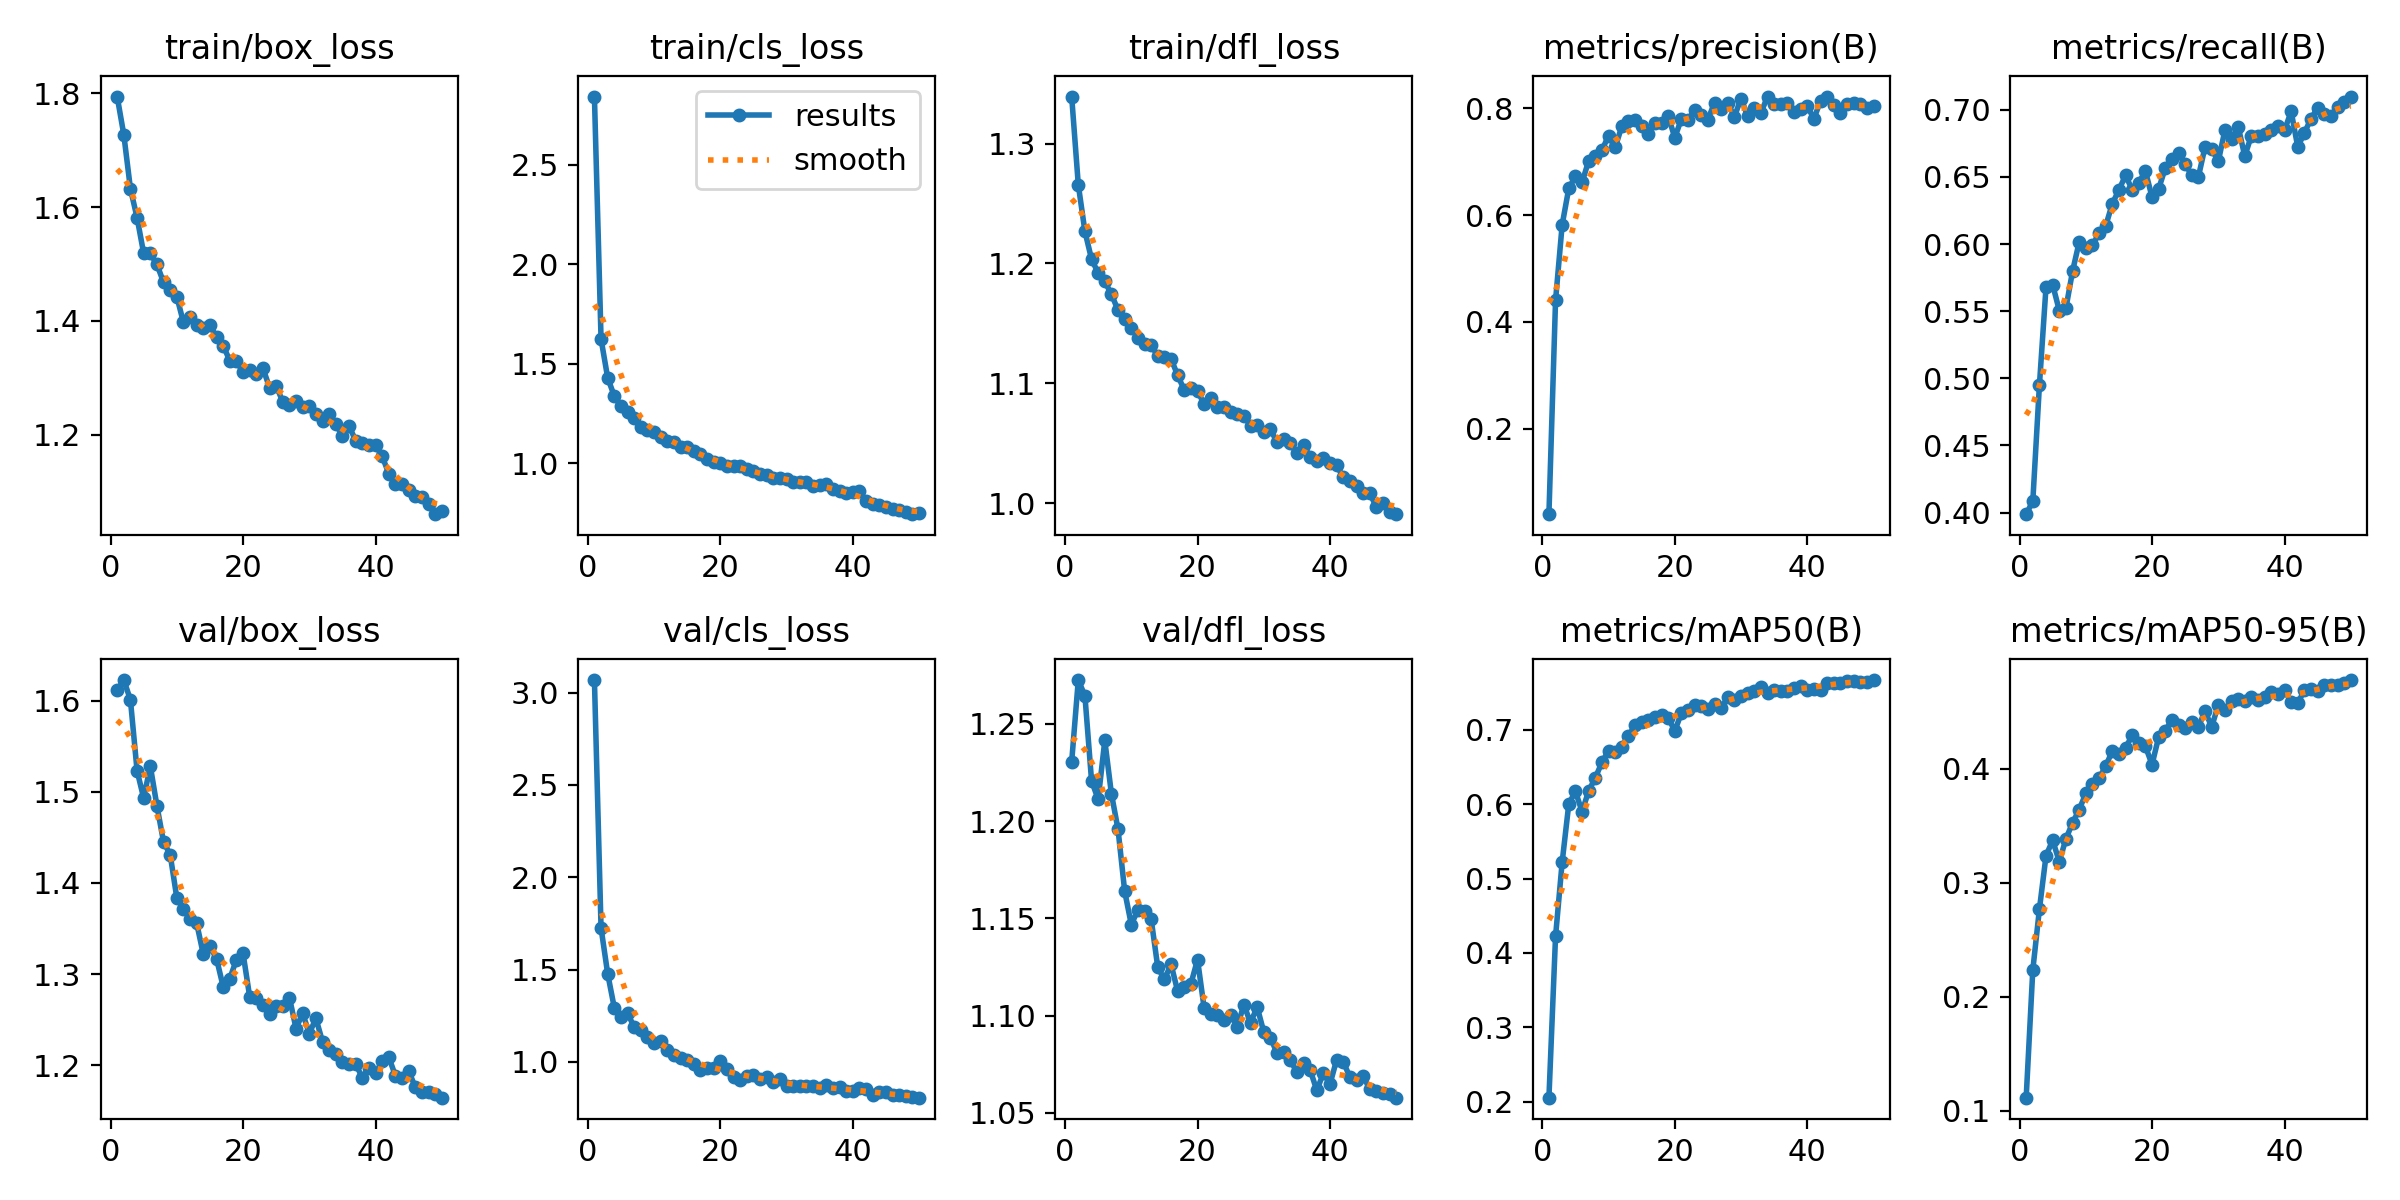

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'/content/datasets/runs/detect/train3/results.png', width=600)

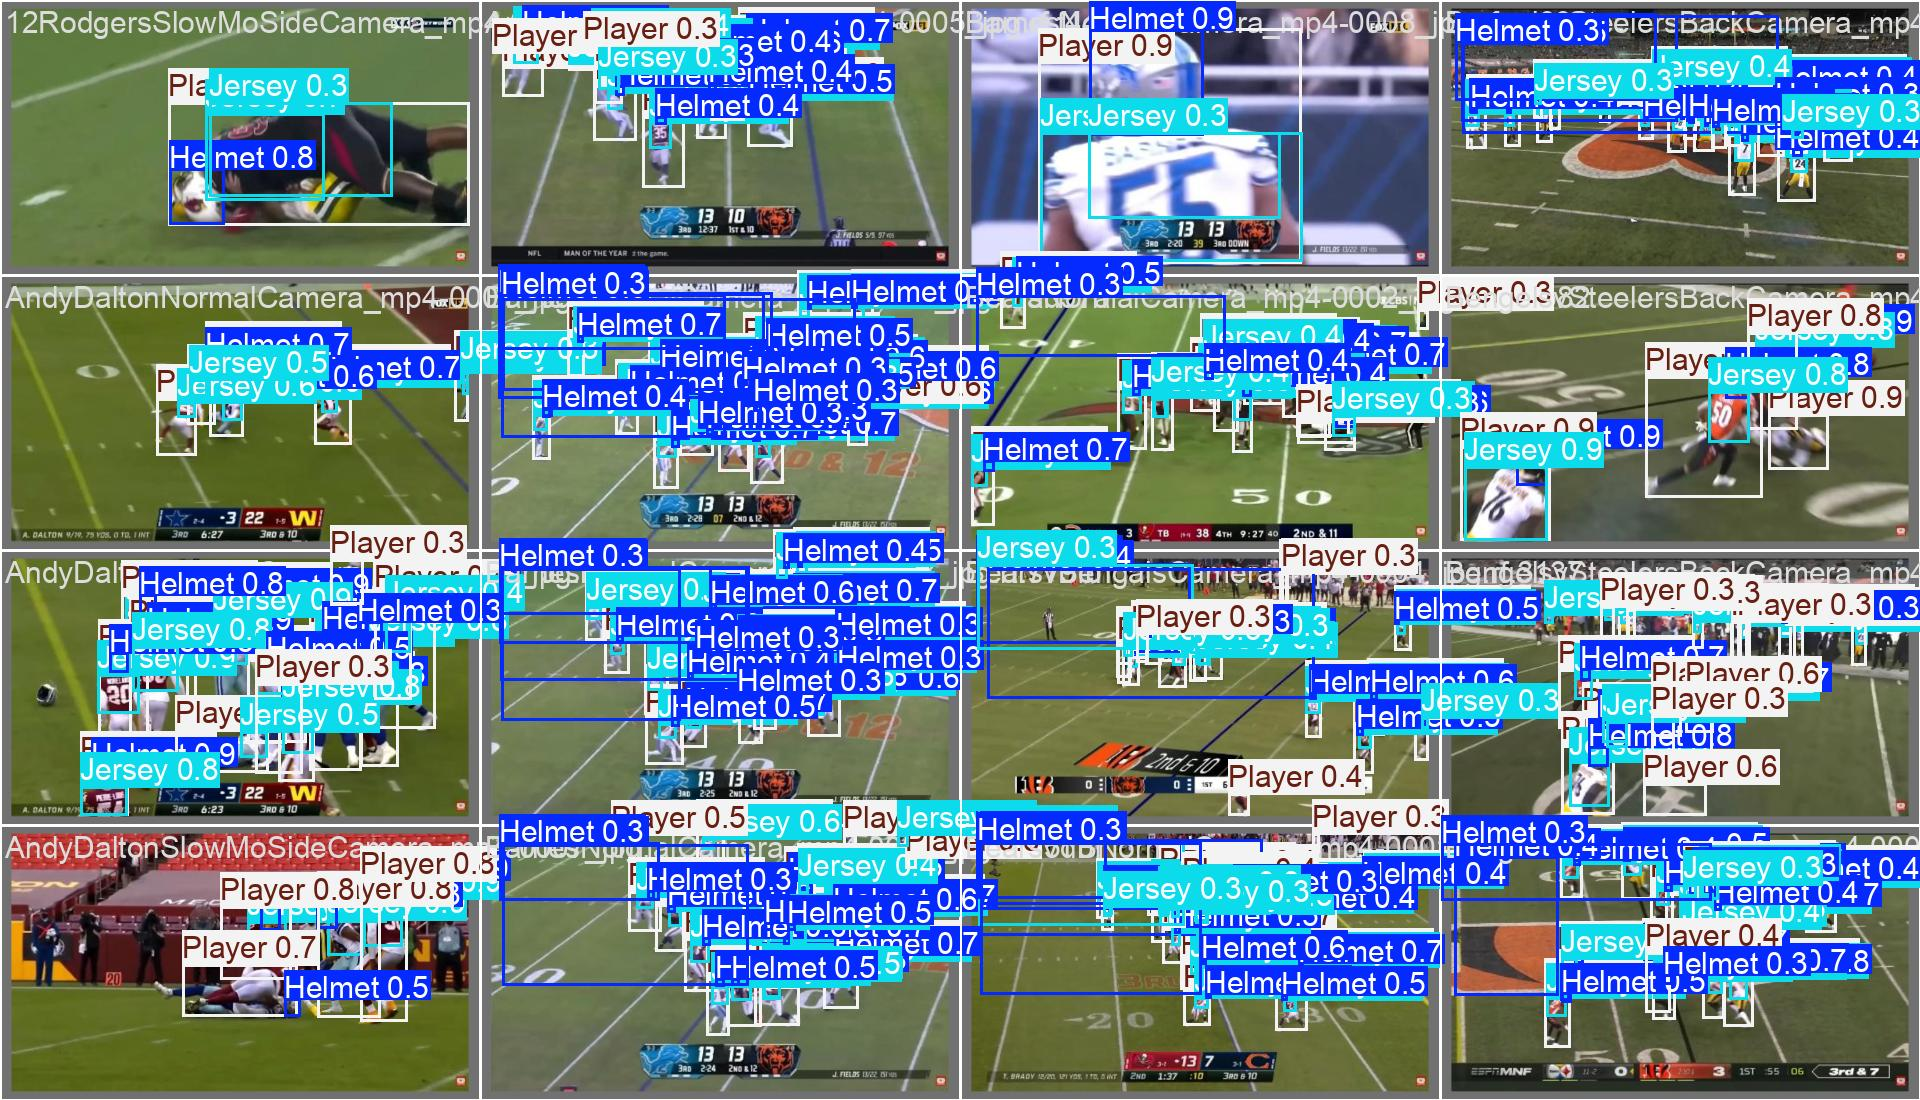

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'/content/datasets/runs/detect/train3/val_batch0_pred.jpg', width=600)

In [ ]:
!yolo task=detect mode=val model=/content/datasets/runs/detect/train3/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1320.5±376.9 MB/s, size: 27.9 KB)
val: Scanning /content/datasets/NFL_Collisions-3/valid/labels.cache... 109 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 109/109 24.1Mit/s 0.0s
val: /content/datasets/NFL_Collisions-3/valid/images/BarnesNormalCamera_mp4-0000_jpg.rf.ad97adccf40c9c131b122422fcff250e.jpg: 1 duplicate labels removed
val: /content/datasets/NFL_Collisions-3/valid/images/BengelsvSteelersBackCamera_mp4-0008_jpg.rf.ff89e8b0d0cfadd824950b1fd14b175c.jpg: 1 duplicate labels removed
val: /content/datasets/NFL_Collisions-3/valid/images/Cobb18BackCamera_mp4-0003_jpg.rf.13633577cfb22aabab7d31f793c0f395.jpg: 1 duplicate labels removed
val: /content/datasets/NFL_Collisions-3/valid/images/Cobb18BackCamera_mp4-0005_jpg.rf.5004021a2df28439056ee50e4d639bd7.jpg: 1 duplicate l

In [ ]:
!yolo task=detect mode=predict model=/content/datasets/runs/detect/train3/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs

image 1/106 /content/datasets/NFL_Collisions-3/test/images/12RodgersSlowMoSideCamera_mp4-0000_jpg.rf.3899e82549acf7fe930fb20fe1c2ed5a.jpg: 384x640 12 Helmets, 15 Jerseys, 13 Players, 49.9ms
image 2/106 /content/datasets/NFL_Collisions-3/test/images/AZ26NormalCamera_mp4-0002_jpg.rf.63af739538271d52ff854e64b35bf10e.jpg: 384x640 5 Helmets, 5 Jerseys, 10 Players, 8.3ms
image 3/106 /content/datasets/NFL_Collisions-3/test/images/Addams17NormalCamera_mp4-0004_jpg.rf.9e59a1d9f0fbadf9eedbbbba72e393df.jpg: 384x640 11 Helmets, 12 Jerseys, 11 Players, 7.3ms
image 4/106 /content/datasets/NFL_Collisions-3/test/images/Akins88Texans_mp4-0003_jpg.rf.16e83007b3e76fcc745d30d79a9c6766.jpg: 384x640 3 Helmets, 3 Jerseys, 7 Players, 7.3ms
image 5/106 /content/datasets/NFL_Collisions-3/test/images/AndyDaltonSlowMoSideCamera_mp4-0001_jpg.rf.d48b6bf

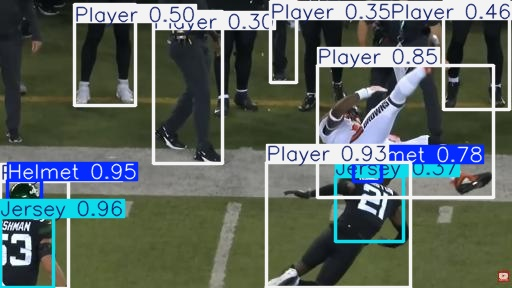

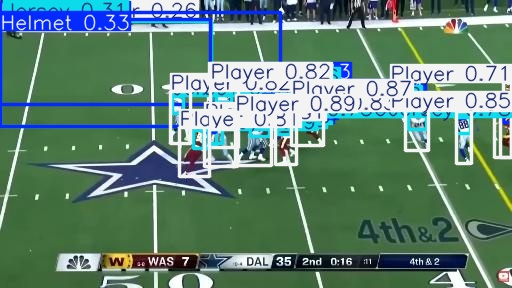

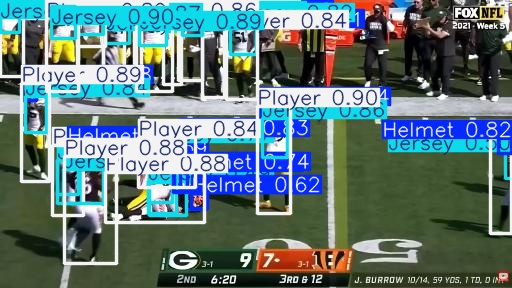

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'/content/datasets/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")